<div style="background:#003B7A;color:white;padding:20px;border-bottom:6px solid #FFC000"><h1>Assignment 1 · Geochemical database audit and anomaly investigation</h1><p>Prof. Glen Nwaila · GEOL5013A · 2026</p></div>

**20 marks · Individual work · Due 27 September 2026, 23:59 SAST**

## Where this fits in the course

Weeks 1–2 teach how observations become a trustworthy database and how exploratory methods identify records needing investigation. This assignment is the first assessed checkpoint. Later work on distributions, variograms and geological models depends on the records, units and joins being defensible.

## Why you are doing this assignment

A plausible-looking prediction can still be wrong if it uses mismatched sample identifiers, coordinate systems or assay units. Here you investigate real rows and justify decisions before modelling. An unusual value is a question to investigate, not an automatic error.

## Intended learning outcomes

- Audit two geochemical tables while preserving raw values and metadata.
- Join records without losing or duplicating their identity.
- Compare anomaly evidence under two justified analytical choices.
- Explain a data decision using identifiable records and reproducible calculations.

## What is supplied and what you must add

Two supplied Strange Lake Excel workbooks, a data/code ZIP and a notebook with baseline audit, join and Isolation Forest code. The baseline is a starting point. You must add the checks, alternative analysis, output tables and written answers below.

Read **A1_Brief_and_Rubric.docx** (or its identical PDF) before running. All assessed questions are repeated below. Run the setup cell first, upload Homework_Data_and_Code.zip when requested, and set your student number. Keep supplied baseline code, then add your own experiments in the marked code cells and written answers in the response cells. Running the baseline alone does not answer the questions.


In [2]:
import os; print(os.getcwd())
LESSON='A1_Geochemical_Database'
from pathlib import Path
import sys, zipfile, json, hashlib
ROOT=Path(os.getcwd()).resolve()
if not (ROOT/'teaching_methods.py').exists():
    from google.colab import files
    print('Upload Homework_Data_and_Code.zip from the Assignments folder.')
    upload=files.upload()
    archives=[ROOT/name for name in upload if name.endswith('.zip')]
    assert len(archives)==1, 'Upload exactly one homework data ZIP.'
    with zipfile.ZipFile(archives[0]) as archive:
        for member in archive.namelist():
            assert (ROOT/member).resolve().is_relative_to(ROOT)
        archive.extractall(ROOT)
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from teaching_methods import *
STUDENT_NUMBER='2539990' # Replace with your own student number before the first run.
SEED=2026+int(''.join(c for c in STUDENT_NUMBER if c.isdigit())[-4:])
DATA=ROOT/'Homework_Data'
OUT=Path(os.getcwd())/'Outputs'/LESSON
OUT.mkdir(parents=True,exist_ok=True)
rng=np.random.default_rng(SEED)
def save_figure(fig,name):
    for ext in ['png','pdf']:fig.savefig(OUT/f'{name}.{ext}',dpi=180,bbox_inches='tight')
    plt.show()
manifest={'student_number':STUDENT_NUMBER,'seed':SEED,'numpy':np.__version__,'pandas':pd.__version__,
          'inputs':{p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA.iterdir() if p.is_file()}}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
print('Output directory:',OUT)


/content
Output directory: /content/Outputs/A1_Geochemical_Database


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q1. What must be checked before these tables can be used? · 5 marks</h2>

**Q1.1.** Inspect both workbooks before cleaning. Record dimensions, candidate key, coordinate columns, chemical columns and metadata rows. Preserve the new workbook's units row separately. Distinguish a missing-key metadata row from a sample with a missing identifier.

**Q1.2.** Make data_dictionary.csv for the sample key, both coordinate pairs and five chemical variables you choose. Include workbook, original column name, meaning, recorded unit, coordinate reference where applicable, source of the definition and any unresolved assumption.

**Q1.3.** Count missing keys, duplicate keys, missing values and nonnumeric or censored entries in the selected chemical columns. Save audit.csv with workbook, check, affected column, count and proposed action. Keep original strings beside any numerical replacement. A zero finding must still be recorded.

**Q1.4.** In 150–200 words, identify the two findings that most affect later analysis. Cite actual columns and counts and explain whether you would retain, query or correct them. Do not guess undocumented units.

**Marking criteria:** Dictionary and metadata: 2; implemented checks and counts: 2; interpretation of consequences: 1.

**What good work looks like:** A reader can locate the cited raw rows, see the original units and reproduce each audit count. The explanation distinguishes observations from assumptions.


<h2 style="color:#003B7A">1. Inspect the raw tables</h2>

The new workbook contains a units row. Preserve it before selecting sample records. A record without a sample key is not automatically a sample with missing data.

**Expected output and check:** Check row counts, key uniqueness and the units row. Do not assume the old and new assays use identical methods or units.


In [3]:
old=pd.read_excel(DATA/'Strange_Lake_OLD.xlsx')
new_raw=pd.read_excel(DATA/'Strange_Lake_NEW.xlsx')
metadata_rows=new_raw[new_raw['Unique ID'].isna()].copy()
new=new_raw[new_raw['Unique ID'].notna()].copy()
metadata_rows.to_csv(OUT/'new_workbook_metadata_rows.csv',index=False)
audit=pd.DataFrame([{'table':name,'rows':len(df),'missing_keys':int(df['Unique ID'].isna().sum()),'duplicate_keys':int(df['Unique ID'].duplicated().sum())} for name,df in [('old',old),('new_samples',new)]])
audit.to_csv(OUT/'audit.csv',index=False)
display(audit,metadata_rows,old.head(),new.head())


,table,rows,missing_keys,duplicate_keys
0,old,3441,0,0
1,new_samples,3441,0,0


,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM


,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Zn,Cu,Pb,Ni,Co,Ag,Mn,Fe,As,Mo,F,LOI,Hg,U
0,013L781002,013L,54.989093,-62.019071,40,38,<2,43,10,<0.2,70,1.00,<1,2,85,23,40,0.3
1,013L781003,013L,54.975382,-62.030577,40,44,<2,35,8,<0.2,80,1.90,<1,<2,80,33,70,0.5
2,013L781004,013L,54.976331,-62.044913,46,30,<2,34,8,<0.2,80,0.70,<1,2,90,27.2,50,0.6
3,013L781005,013L,54.973541,-62.054790,50,26,<2,22,6,<0.2,120,0.85,<1,2,60,29.6,40,0.6
4,013L781007,013L,54.936983,-62.026399,42,20,<2,22,9,<0.2,100,0.70,<1,2,65,33.6,60,0.3


,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
1,013L781002,Routine,013L,54.98900,-62.01995,57,2.89,<0.1,1,<20,...,0.021,0.03,0.1,0.3,31,<0.1,6.04,0.64,44,0.9
2,013L781003,Routine,013L,54.97529,-62.03145,106,3.22,0.1,1.6,<20,...,0.021,0.03,0.08,0.3,45,<0.1,5.65,0.49,45.1,1
3,013L781004,Routine,013L,54.97623,-62.04579,59,2.34,0.1,1.1,<20,...,0.023,0.04,0.09,0.3,17,<0.1,7.19,0.64,51.4,0.8
4,013L781005,First Field Duplicate,013L,54.97344,-62.05566,70,2.26,0.1,0.9,<20,...,0.014,0.03,0.12,0.6,34,<0.1,8.08,0.74,51.1,0.8
5,013L781007,Routine,013L,54.93689,-62.02727,62,1.89,<0.1,0.3,<20,...,0.021,0.05,0.1,0.3,28,<0.1,7.53,0.61,45.4,0.9


In [4]:
# Add your Q1 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.

# ============================================================
# Q1 — GEOCHEMICAL DATABASE AUDIT
# ============================================================

# Q1.1 — Inspect raw tables

chemicals = ['Cu', 'Zn', 'U', 'Fe', 'Mn']

print("OLD shape:", old.shape)
print("NEW raw shape:", new_raw.shape)
print("NEW samples:", new.shape)

print("\nCandidate key: Unique ID")
print("OLD coordinates:", ['Latitude_NAD83', 'Longitude_NAD83'])
print("NEW coordinates:", ['Latitude (NAD 27)', 'Longitude (NAD 27)'])
print("Selected chemicals:", chemicals)

print("\nMetadata rows:", len(metadata_rows))
print("Missing sample IDs after metadata removal:", new['Unique ID'].isna().sum())

display(metadata_rows)

# Q1.2 — Data dictionary

rows = [
    ['OLD','Unique ID','Sample identifier','N/A','N/A','Column name','None'],
    ['NEW','Unique ID','Sample identifier','N/A','N/A','Column name','None'],
    ['OLD','Latitude_NAD83','Latitude','Not documented','NAD83','Column name','Exact CRS not supplied'],
    ['OLD','Longitude_NAD83','Longitude','Not documented','NAD83','Column name','Exact CRS not supplied'],
    ['NEW','Latitude (NAD 27)','Latitude','Not documented','NAD27','Column name','Exact CRS not supplied'],
    ['NEW','Longitude (NAD 27)','Longitude','Not documented','NAD27','Column name','Exact CRS not supplied']
]

for c in chemicals:
    rows.append(['OLD', c, f'{c} measurement', 'Not documented',
                 'N/A', 'Column name', 'Unit/method not supplied'])
    rows.append(['NEW', c, f'{c} measurement', metadata_rows.iloc[0][c],
                 'N/A', 'Units row', 'Method comparability unknown'])

data_dictionary = pd.DataFrame(rows, columns=[
    'workbook','original_column_name','meaning','recorded_unit',
    'coordinate_reference','source_of_definition','unresolved_assumption'
])

data_dictionary.to_csv(OUT/'data_dictionary.csv', index=False)
display(data_dictionary)

# Q1.3 — Audit

audit_rows = []

for name, df in [('OLD', old), ('NEW', new)]:
    audit_rows += [
        [name, 'missing keys', 'Unique ID',
         df['Unique ID'].isna().sum(), 'Investigate'],
        [name, 'duplicate keys', 'Unique ID',
         df['Unique ID'].duplicated().sum(), 'Investigate before join']
    ]

    for c in chemicals:
        s = df[c]
        text = s.astype('string').str.strip()
        censored = text.str.match(r'^[<>]', na=False)
        numeric = pd.to_numeric(s, errors='coerce')

        audit_rows += [
            [name, 'missing values', c, s.isna().sum(), 'Retain as missing'],
            [name, 'censored entries', c, censored.sum(),
             'Preserve original; treat explicitly'],
            [name, 'other nonnumeric', c,
             (s.notna() & numeric.isna() & ~censored).sum(),
             'Inspect original value']
        ]

# Record metadata separately
audit_rows.append(
    ['NEW', 'metadata row', 'Unique ID', len(metadata_rows),
     'Preserve separately']
)

audit = pd.DataFrame(audit_rows, columns=[
    'workbook','check','affected_column','count','proposed_action'
])

audit.to_csv(OUT/'audit.csv', index=False)
display(audit)

# Preserve original and numeric versions

for c in chemicals:
    new[c + '_original'] = new[c]
    new[c + '_numeric'] = pd.to_numeric(new[c], errors='coerce')

    old[c + '_original'] = old[c]
    old[c + '_numeric'] = pd.to_numeric(old[c], errors='coerce')

OLD shape: (3441, 18)
NEW raw shape: (3442, 70)
NEW samples: (3441, 70)

Candidate key: Unique ID
OLD coordinates: ['Latitude_NAD83', 'Longitude_NAD83']
NEW coordinates: ['Latitude (NAD 27)', 'Longitude (NAD 27)']
Selected chemicals: ['Cu', 'Zn', 'U', 'Fe', 'Mn']

Metadata rows: 1
Missing sample IDs after metadata removal: 0


,Unique ID,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),Ag,Al,As,Au,B,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,NaN,NaN,NaN,NaN,NaN,PPB,%,PPM,PPB,PPM,...,%,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM,PPM


,workbook,original_column_name,meaning,recorded_unit,coordinate_reference,source_of_definition,unresolved_assumption
0,OLD,Unique ID,Sample identifier,N/A,N/A,Column name,None
1,NEW,Unique ID,Sample identifier,N/A,N/A,Column name,None
2,OLD,Latitude_NAD83,Latitude,Not documented,NAD83,Column name,Exact CRS not supplied
3,OLD,Longitude_NAD83,Longitude,Not documented,NAD83,Column name,Exact CRS not supplied
4,NEW,Latitude (NAD 27),Latitude,Not documented,NAD27,Column name,Exact CRS not supplied
5,NEW,Longitude (NAD 27),Longitude,Not documented,NAD27,Column name,Exact CRS not supplied
6,OLD,Cu,Cu measurement,Not documented,N/A,Column name,Unit/method not supplied
7,NEW,Cu,Cu measurement,PPM,N/A,Units row,Method comparability unknown
8,OLD,Zn,Zn measurement,Not documented,N/A,Column name,Unit/method not supplied
9,NEW,Zn,Zn measurement,PPM,N/A,Units row,Method comparability unknown


,workbook,check,affected_column,count,proposed_action
0,OLD,missing keys,Unique ID,0,Investigate
1,OLD,duplicate keys,Unique ID,0,Investigate before join
2,OLD,missing values,Cu,0,Retain as missing
3,OLD,censored entries,Cu,0,Preserve original; treat explicitly
4,OLD,other nonnumeric,Cu,0,Inspect original value
5,OLD,missing values,Zn,0,Retain as missing
6,OLD,censored entries,Zn,0,Preserve original; treat explicitly
7,OLD,other nonnumeric,Zn,0,Inspect original value
8,OLD,missing values,U,0,Retain as missing
9,OLD,censored entries,U,11,Preserve original; treat explicitly


### Your Q1 response

Two findings have the greatest consequences for later analysis. First, the raw NEW workbook contains 3,442 rows, but one row with a missing `Unique ID` is a metadata row containing measurement units rather than a sample observation. After preserving this row separately, both the OLD and NEW sample tables contain 3,441 records, with zero missing and zero duplicate sample identifiers. I would retain the metadata row separately and exclude it from sample-level calculations and joins because treating it as a sample would introduce invalid values.

Second, the chemical audit identified censored and nonnumeric measurements that require explicit treatment before modelling. The OLD `U` column contains 11 censored entries, while the NEW `Mn` column contains 34 censored entries and one additional nonnumeric entry. I would retain the original strings and investigate or apply a documented censored-value treatment rather than silently deleting or replacing them. The NEW metadata records Cu, Zn, U and Mn in PPM and Fe in %, but equivalent units are not documented in the supplied OLD workbook. Therefore, direct numerical comparability between OLD and NEW assays should not be assumed without additional source metadata.


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q2. Can every joined record be traced to its sources? · 6 marks</h2>

**Q2.1.** Use the sample identifier to perform an outer join with a merge indicator. Demonstrate key uniqueness before using a one-to-one join. If uniqueness fails, export the offending rows and document a justified resolution before proceeding; do not silently drop duplicates.

**Q2.2.** Save joined_samples.csv and join_counts.csv. Report left-only, right-only and matched counts. Demonstrate that output count equals the sum of those three counts; reconcile original unique-key counts with matched and unmatched counts.

**Q2.3.** Use the five IDs selected by the notebook's student-number seed. Save five_sample_trace.csv showing the ID, source workbook and row index, join status, and original values for at least two chemicals and the coordinate fields. Include missing counterparts explicitly.

**Q2.4.** In 150–200 words, explain why NAD83 and NAD27 numbers cannot be assumed to describe identical positions. State what metadata or transformation would be needed for comparison. Identify one documented analytical-method or unit-comparability issue, or explain precisely what evidence is missing.

**Marking criteria:** Five-record trace: 2; join checks and count reconciliation: 2; coordinate and analytical comparability: 2.

**What good work looks like:** The five trace records match your seed and join output. Your explanation uses the supplied coordinate metadata without inventing a transformation.


<h2 style="color:#003B7A">2. Trace the relational join</h2>

The merge indicator exposes unmatched records. Select a reproducible set of sample identifiers for manual comparison.

**Expected output and check:** The merge must not multiply sample records. Explain the NAD83/NAD27 distinction before comparing coordinates.


In [5]:
joined=old.merge(new,on='Unique ID',how='outer',suffixes=('_old','_new'),indicator=True,validate='one_to_one')
joined.to_csv(OUT/'joined_samples.csv',index=False)
selected=np.sort(rng.choice(joined['Unique ID'].astype(str),size=5,replace=False))
trace=joined[joined['Unique ID'].astype(str).isin(selected)]
trace.to_csv(OUT/'five_sample_trace.csv',index=False)
joined['_merge'].value_counts().rename_axis('join_status').to_csv(OUT/'join_counts.csv')
display(trace[['Unique ID','_merge','Cu_old','Cu_new']])


,Unique ID,_merge,Cu_old,Cu_new
171,013L783024,both,12,11.98
1146,013M783158,both,26,24.49
2467,023I781071,both,76,83.23
2470,023I781075,both,44,48.59
3368,023J783197,both,40,42.13


In [6]:
# Add your Q2 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.


# Q2.1–Q2.2: Key checks, outer join and reconciliation

key = 'Unique ID'

# Demonstrate uniqueness before one-to-one join
print("OLD duplicates:", old[key].duplicated().sum())
print("NEW duplicates:", new[key].duplicated().sum())

assert old[key].is_unique
assert new[key].is_unique

# Outer join
joined = old.merge(
    new, on=key, how='outer',
    suffixes=('_old', '_new'),
    indicator=True,
    validate='one_to_one'
)

# Join counts
counts = joined['_merge'].value_counts()

matched = counts.get('both', 0)
left_only = counts.get('left_only', 0)
right_only = counts.get('right_only', 0)

join_counts = pd.DataFrame({
    'status': ['matched', 'left_only', 'right_only'],
    'count': [matched, left_only, right_only]
})

# Reconciliation checks
assert len(joined) == matched + left_only + right_only
assert old[key].nunique() == matched + left_only
assert new[key].nunique() == matched + right_only

joined.to_csv(OUT/'joined_samples.csv', index=False)
join_counts.to_csv(OUT/'join_counts.csv', index=False)

display(join_counts)

# Q2.3 — Five-sample trace

rng = np.random.default_rng(SEED)
trace_ids = rng.choice(
    sorted(joined['Unique ID'].dropna().unique()),
    size=5,
    replace=False
)

trace = []

for ID in trace_ids:
    for source, df, lat, lon in [
        ('OLD', old, 'Latitude_NAD83', 'Longitude_NAD83'),
        ('NEW', new, 'Latitude (NAD 27)', 'Longitude (NAD 27)')
    ]:
        row = df[df['Unique ID'] == ID]

        trace.append({
            'Unique ID': ID,
            'source_workbook': source,
            'row_index': row.index[0] if not row.empty else pd.NA,
            'join_status': joined.loc[
                joined['Unique ID'] == ID, '_merge'
            ].iloc[0],
            'Cu': row['Cu'].iloc[0] if not row.empty else pd.NA,
            'Zn': row['Zn'].iloc[0] if not row.empty else pd.NA,
            'Latitude': row[lat].iloc[0] if not row.empty else pd.NA,
            'Longitude': row[lon].iloc[0] if not row.empty else pd.NA
        })

five_sample_trace = pd.DataFrame(trace)
five_sample_trace.to_csv(OUT/'five_sample_trace.csv', index=False)

print("Seed:", SEED)
print("Selected IDs:", trace_ids)
display(five_sample_trace)

OLD duplicates: 0
NEW duplicates: 0


,status,count
0,matched,3441
1,left_only,0
2,right_only,0


Seed: 12016
Selected IDs: ['013M783158' '023I781075' '023J783197' '013L783024' '023I781071']


,Unique ID,source_workbook,row_index,join_status,Cu,Zn,Latitude,Longitude
0,013M783158,OLD,1146,both,26.00,200.0,55.252338,-63.530600
1,013M783158,NEW,1147,both,24.49,172.4,55.252240,-63.531440
2,023I781075,OLD,2470,both,44.00,154.0,54.558262,-65.360768
3,023I781075,NEW,2471,both,48.59,179.3,54.558160,-65.361560
4,023J783197,OLD,3368,both,40.00,170.0,54.585451,-66.872653
5,023J783197,NEW,3369,both,42.13,172.7,54.585350,-66.873370
6,013L783024,OLD,171,both,12.00,184.0,54.715834,-63.178151
7,013L783024,NEW,172,both,11.98,190.3,54.715780,-63.178990
8,023I781071,OLD,2467,both,76.00,138.0,54.575207,-65.277773
9,023I781071,NEW,2468,both,83.23,156.7,54.575110,-65.278560


### Your Q2 response
The OLD and NEW coordinate values cannot be assumed to represent identical positions because they are referenced to different geodetic datums. The OLD workbook labels its coordinates as `Latitude_NAD83` and `Longitude_NAD83`, whereas the NEW workbook uses `Latitude (NAD 27)` and `Longitude (NAD 27)`. Therefore, numerical differences between the coordinate pairs could reflect the different reference datums rather than actual changes in sample location. Before comparing coordinates directly, the complete coordinate reference system metadata would be required, including the datum definition and an appropriate CRS identifier where available. One dataset would then need to be transformed into the same coordinate reference system as the other using a documented transformation rather than manually treating the numbers as equivalent.

Analytical comparability also remains unresolved. The preserved NEW metadata row records Cu, Zn, U and Mn in PPM and Fe in %, while corresponding units are not documented in the supplied OLD workbook. In addition, the supplied tables do not establish that the same analytical methods or detection limits were used. I would therefore retain both measurements but avoid assuming direct assay equivalence until supporting laboratory or source metadata is obtained.


<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q3. Which unusual records deserve investigation, and why? · 5 marks</h2>

**Q3.1.** Run the supplied complete-case Cu–Zn–U baseline. Record the number excluded from this feature matrix, scaling method, detector settings and seed. Save the baseline score and rank for each eligible ID.

**Q3.2.** Implement one justified alternative: change the feature set, or use an explicit treatment of censored values. State the scientific reason before comparing outputs. Preserve IDs and report eligible counts for both runs.

**Q3.3.** Compare five IDs eligible for both analyses. Prefer records where ranking or classification differs. If there are no classification disagreements, select the largest rank changes and report honestly that classifications agree. Do not invent disagreement. These five IDs may differ from Q2's trace sample.

**Q3.4.** Save anomaly_decisions.csv with ID, input values and units, both scores/ranks, available old/new assay evidence, decision (retain/query/exclude), reason and unresolved evidence. Explain the five decisions in 200–300 words. Anomaly status alone is not sufficient grounds for exclusion.

**Marking criteria:** Identifiable records and alternative comparison: 2; source/context evidence: 2; justified decisions: 1.

**What good work looks like:** Each recommendation refers to actual values and distinguishes a statistical anomaly from a demonstrated database or assay error.


<h2 style="color:#003B7A">3. Baseline anomaly evidence</h2>

The baseline ranks complete numeric Cu, Zn and U records in the new table. Censored strings remain missing for this diagnostic and are counted; this is not a universal censoring solution.

**Expected output and check:** Add the alternative feature or censoring treatment required by the brief. A large score does not prove a laboratory error.


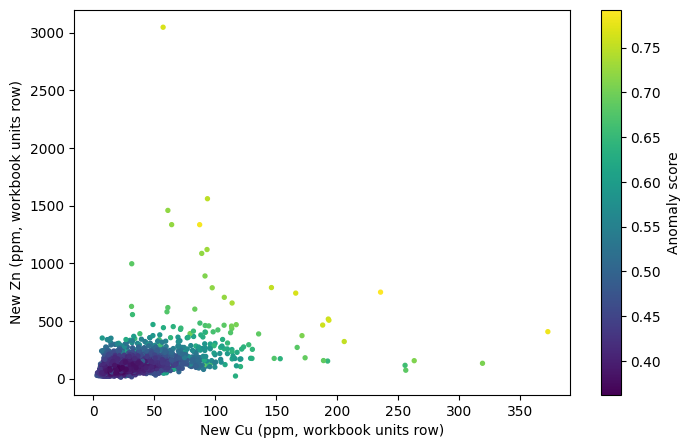

,Unique ID,Cu,Zn,U,anomaly_score
2118,014D783298,235.67,750.2,5.9,0.792244
3198,023J781325,87.22,1334.8,21.6,0.787012
2933,023I823079,372.97,407.6,10.9,0.781705
3329,023J783145,57.23,3046,16.7,0.767034
3057,023J781134,166.05,741.7,3.5,0.765468
2942,023I823092,193.3,506.8,4.9,0.764338
2968,023J781029,188.17,464.7,6.3,0.758658
2449,023I781043,192.79,517,2.7,0.757239
3213,023J783007,146.13,789.8,2.6,0.752027
3364,023J783192,205.86,322.1,7.5,0.751935


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
features=new[['Cu','Zn','U']].apply(pd.to_numeric,errors='coerce')
complete=features.notna().all(axis=1)
features.isna().sum().rename('non_numeric_or_missing').to_csv(OUT/'feature_exclusions.csv')
X=StandardScaler().fit_transform(features.loc[complete])
detector=IsolationForest(contamination=.02,random_state=SEED).fit(X)
rank=new.loc[complete,['Unique ID','Cu','Zn','U']].copy()
rank['anomaly_score']=-detector.score_samples(X)
rank.sort_values('anomaly_score',ascending=False).to_csv(OUT/'baseline_anomaly_ranking.csv',index=False)
fig,ax=plt.subplots(figsize=(8,5));p=ax.scatter(features.loc[complete,'Cu'],features.loc[complete,'Zn'],c=rank.anomaly_score,s=8);fig.colorbar(p,ax=ax,label='Anomaly score');ax.set(xlabel='New Cu (ppm, workbook units row)',ylabel='New Zn (ppm, workbook units row)');save_figure(fig,'anomaly_feature_view')
display(rank.nlargest(10,'anomaly_score'))


In [8]:
# Add your Q3 checks, experiments and required file exports here.
# Use OUT for saved tables and PDF/PNG figures.

# Q3.1 — Baseline: Cu, Zn, U

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features1 = ['Cu', 'Zn', 'U']

X1 = new[['Unique ID'] + features1].copy()
for c in features1:
    X1[c] = pd.to_numeric(X1[c], errors='coerce')

excluded1 = X1[features1].isna().any(axis=1).sum()
X1 = X1.dropna()

scaler = StandardScaler()
Z1 = scaler.fit_transform(X1[features1])

model1 = IsolationForest(
    contamination=0.05,
    random_state=SEED
)

model1.fit(Z1)

X1['baseline_score'] = model1.decision_function(Z1)
X1['baseline_class'] = model1.predict(Z1)
X1['baseline_rank'] = X1['baseline_score'].rank(method='min')

X1.to_csv(OUT/'baseline_anomaly_scores.csv', index=False)

print("Eligible:", len(X1), "| Excluded:", excluded1)
print("Scaling: StandardScaler")
print("Contamination: 0.05 | Seed:", SEED)

# Q3.2 — Alternative: Cu, Zn, U, Mn

features2 = ['Cu', 'Zn', 'U', 'Mn']

X2 = new[['Unique ID'] + features2].copy()
for c in features2:
    X2[c] = pd.to_numeric(X2[c], errors='coerce')

excluded2 = X2[features2].isna().any(axis=1).sum()
X2 = X2.dropna()

Z2 = StandardScaler().fit_transform(X2[features2])

model2 = IsolationForest(
    contamination=0.05,
    random_state=SEED
)

model2.fit(Z2)

X2['alternative_score'] = model2.decision_function(Z2)
X2['alternative_class'] = model2.predict(Z2)
X2['alternative_rank'] = X2['alternative_score'].rank(method='min')

print("Baseline eligible:", len(X1))
print("Alternative eligible:", len(X2))
print("Alternative excluded:", excluded2)

# Q3.3 — Compare baseline and alternative

compare = X1.merge(
    X2[['Unique ID','Mn','alternative_score',
        'alternative_class','alternative_rank']],
    on='Unique ID'
)

compare['rank_change'] = abs(
    compare['baseline_rank'] - compare['alternative_rank']
)

different = compare[
    compare['baseline_class'] != compare['alternative_class']
]

if len(different) >= 5:
    five = different.nlargest(5, 'rank_change')
    print("Selected classification disagreements.")
else:
    five = compare.nlargest(5, 'rank_change')
    print("Fewer than five classification disagreements; "
          "selected largest rank changes.")

display(five)


# Q3.4 — Anomaly decisions

decisions = five.rename(columns={
    'Cu':'new_Cu', 'Zn':'new_Zn',
    'U':'new_U', 'Mn':'new_Mn'
}).copy()

old_evidence = old[['Unique ID','Cu','Zn','U','Mn']].copy()
old_evidence.columns = [
    'Unique ID','old_Cu','old_Zn','old_U','old_Mn'
]

decisions = decisions.merge(old_evidence, on='Unique ID', how='left')

decisions['units'] = 'NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented'
decisions['decision'] = 'query'
decisions['reason'] = (
    'Normal in baseline but anomalous after Mn was added.'
)
decisions['unresolved_evidence'] = (
    'OLD units/method comparability not documented.'
)

decisions.to_csv(OUT/'anomaly_decisions.csv', index=False)
display(decisions)

Eligible: 3440 | Excluded: 1
Scaling: StandardScaler
Contamination: 0.05 | Seed: 12016
Baseline eligible: 3440
Alternative eligible: 3406
Alternative excluded: 35
Selected classification disagreements.


,Unique ID,Cu,Zn,U,baseline_score,baseline_class,baseline_rank,Mn,alternative_score,alternative_class,alternative_rank,rank_change
932,013M781525,20.33,75.2,1.6,0.218297,1,3422.0,7308.0,-0.059993,-1,78.0,3344.0
1911,014D783063,30.24,110.6,1.9,0.209083,1,3127.0,6565.0,-0.034296,-1,113.0,3014.0
1485,014D781076,11.75,73.0,1.7,0.206168,1,2924.0,7905.0,-0.085867,-1,44.0,2880.0
1987,014D783153,24.22,86.8,4.0,0.202683,1,2676.0,7613.0,-0.077295,-1,56.0,2620.0
1260,013M783296,9.76,62.7,0.5,0.201505,1,2601.0,8108.0,-0.094318,-1,39.0,2562.0


,Unique ID,new_Cu,new_Zn,new_U,baseline_score,baseline_class,baseline_rank,new_Mn,alternative_score,alternative_class,alternative_rank,rank_change,old_Cu,old_Zn,old_U,old_Mn,units,decision,reason,unresolved_evidence
0,013M781525,20.33,75.2,1.6,0.218297,1,3422.0,7308.0,-0.059993,-1,78.0,3344.0,16,72,1.6,6600,NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented,query,Normal in baseline but anomalous after Mn was ...,OLD units/method comparability not documented.
1,014D783063,30.24,110.6,1.9,0.209083,1,3127.0,6565.0,-0.034296,-1,113.0,3014.0,30,114,1.9,7900,NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented,query,Normal in baseline but anomalous after Mn was ...,OLD units/method comparability not documented.
2,014D781076,11.75,73.0,1.7,0.206168,1,2924.0,7905.0,-0.085867,-1,44.0,2880.0,12,70,2.3,7700,NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented,query,Normal in baseline but anomalous after Mn was ...,OLD units/method comparability not documented.
3,014D783153,24.22,86.8,4.0,0.202683,1,2676.0,7613.0,-0.077295,-1,56.0,2620.0,22,78,4,6300,NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented,query,Normal in baseline but anomalous after Mn was ...,OLD units/method comparability not documented.
4,013M783296,9.76,62.7,0.5,0.201505,1,2601.0,8108.0,-0.094318,-1,39.0,2562.0,8,64,0.8,8100,NEW: Cu/Zn/U/Mn = PPM; OLD units undocumented,query,Normal in baseline but anomalous after Mn was ...,OLD units/method comparability not documented.


### Your Q3 response

The Cu–Zn–U baseline contained 3,440 eligible records, with one record excluded because the complete-case feature matrix was incomplete. Adding Mn as the alternative feature reduced the eligible dataset to 3,406 records, with 35 excluded. This reduction is consistent with the data audit showing that Mn contains values that cannot all be used directly as numeric complete cases.

The five selected records demonstrate how the choice of variables affects anomaly detection. All five were classified as normal in the Cu–Zn–U baseline but became anomalies after Mn was included. For example, `013M781525` changed from baseline rank 3422 to alternative rank 78 and has Mn of 7,308 ppm. `014D781076` changed from rank 2924 to 44 with Mn of 7,905 ppm, while `013M783296` changed from rank 2601 to 39 and has Mn of 8,108 ppm. The other two records, `014D783063` and `014D783153`, show similar changes with Mn values of 6,565 and 7,613 ppm respectively.

I classify all five records as **query**, rather than exclude. Their strong rank changes show that Mn makes them statistically unusual, but this does not demonstrate measurement or database error. The original OLD measurements should therefore be examined for supporting or conflicting evidence. A final exclusion decision cannot be justified because the supplied OLD workbook does not document equivalent units or analytical-method comparability.



<h2 style="color:#003B7A;border-left:6px solid #FFC000;padding-left:12px">Q4. Is the workflow reproducible, and which choice do you defend? · 4 marks</h2>

**Q4.1.** Restart the runtime and run your completed notebook from the beginning. Verify every requested output was recreated. Include a manifest with input hashes, student number/seed, library versions and your configuration.

**Q4.2.** Write a 150–250 word decision log comparing your preferred workflow with one rejected alternative. Quote one numerical consequence, such as a changed eligible count or anomaly rank, and explain why it matters.

**Q4.3.** State one unresolved limitation and declare any assistance, including AI, code reuse and discussion. If no assistance was used, say so. Check the submission list below.

**Marking criteria:** Rerun and manifest: 2; rejected alternative and numerical consequence: 1; clear explanation and assistance declaration: 1.

**What good work looks like:** Another person can reproduce your files and understand the decision without reconstructing undocumented manual edits.


In [9]:
import hashlib, sys, sklearn

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

# Define the paths to the input files
OLD_PATH = DATA/'Strange_Lake_OLD.xlsx'
NEW_PATH = DATA/'Strange_Lake_NEW.xlsx'

manifest = pd.DataFrame({
    'item': [
        'OLD input hash', 'NEW input hash',
        'student_number', 'seed',
        'python', 'pandas', 'numpy', 'scikit-learn',
        'baseline_features', 'alternative_features',
        'scaling', 'contamination'
    ],
    'value': [
        file_hash(OLD_PATH),
        file_hash(NEW_PATH),
        STUDENT_NUMBER, SEED,
        sys.version.split()[0], pd.__version__,
        np.__version__, sklearn.__version__,
        'Cu, Zn, U', 'Cu, Zn, U, Mn',
        'StandardScaler', 0.05
    ]
})

import json

run_manifest = dict(zip(manifest['item'], manifest['value']))

with open(OUT/'run_manifest.json', 'w') as f:
    json.dump(run_manifest, f, indent=4)
display(manifest)

,item,value
0,OLD input hash,7fefe0f2a1c0469aab885f9b4aef33eaaeafab34e714d2...
1,NEW input hash,4d45df2f0fc8d216e568b715598ba7e02b673f4fd3a09c...
2,student_number,2539990
3,seed,12016
4,python,3.13.15
5,pandas,2.2.3
6,numpy,2.1.3
7,scikit-learn,1.6.1
8,baseline_features,"Cu, Zn, U"
9,alternative_features,"Cu, Zn, U, Mn"


### Your Q4 recommendation & assistance declaration
#### Q4.2 - Decision log
My preferred workflow retains the supplied Cu–Zn–U complete-case Isolation Forest as the baseline and compares it with an alternative that adds Mn. I prefer this approach because it preserves the original baseline for reproducibility while testing whether an additional geochemical variable changes which samples appear unusual. All features were scaled using StandardScaler, and the same Isolation Forest configuration and seed were retained so that the main difference between the analyses was the feature set.

I rejected using only the alternative Cu–Zn–U–Mn model as the final analysis. Adding Mn reduced the eligible sample count from 3,440 to 3,406, meaning 34 additional records could not participate in the analysis. It also substantially changed some anomaly rankings. For example, sample `013M783296` changed from baseline rank 2601 to alternative rank 39 after Mn was included, with a NEW Mn value of 8,108 ppm.

This consequence matters because anomaly detection is sensitive to feature selection. Rather than treating either result as automatically correct, I retain the baseline and use the alternative as supporting evidence for identifying records that require further investigation.

#### Q4.3 - Limitation & assistance declaration

**Unresolved limitation:** The supplied OLD workbook does not document equivalent chemical units, analytical methods or detection limits sufficiently to establish direct assay comparability with the NEW workbook. Therefore, differences between OLD and NEW measurements cannot automatically be interpreted as analytical or geological changes.

**Assistance declaration:** I used ChatGPT (OpenAI) to assist with structuring Python code, debugging, interpreting outputs and refining written explanations. I also used Claude to convert the assignment from a JSON file into an IPYNB notebook, and received assistance from my friend Odwa. I executed the code myself, reviewed the generated results against the supplied datasets, and made the final analytical decisions. I also used the code and workflow supplied in the course notebook as the basis for the baseline analysis.




## Submission checklist

Submit STUDENT_A1.ipynb with outputs; STUDENT_A1_Report.pdf (maximum 1,200 words excluding captions/tables/references); audit.csv; data_dictionary.csv; new_workbook_metadata_rows.csv; joined_samples.csv; join_counts.csv; five_sample_trace.csv; anomaly_decisions.csv; run_manifest.json; and Figures.zip containing PDF/PNG plots. No 3D view is required for these tables. Use your student number in place of STUDENT. The report synthesises the answers; do not add a second unrelated essay. Word limits exclude tables, captions, references and code. Keep your detailed evidence in the notebook. Save 2D figures as PDF and PNG below os.getcwd(); no 3D view is required for these assignments.

- Answer every numbered subquestion.
- Save each named output and check that it opens.
- Include actual evidence for each interpretation.
- Run the archive cell only after completing your work.


In [10]:
import shutil
archive=shutil.make_archive(str(OUT),'zip',root_dir=OUT)
print('Download your evidence:',archive)


Download your evidence: /content/Outputs/A1_Geochemical_Database.zip
